In [3]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import os
from datetime import datetime
from openpyxl import load_workbook, Workbook
import pandas as pd
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense
import numpy as np

## red wine quality

In [4]:
red = pd.read_csv("redwinequality.csv", sep=';')
white = pd.read_csv("whitewinequality.csv", sep=';')

red['type'] = 1
white['type'] = 0

wines = pd.concat([red, white], ignore_index=True)
wines.dropna(inplace=True)

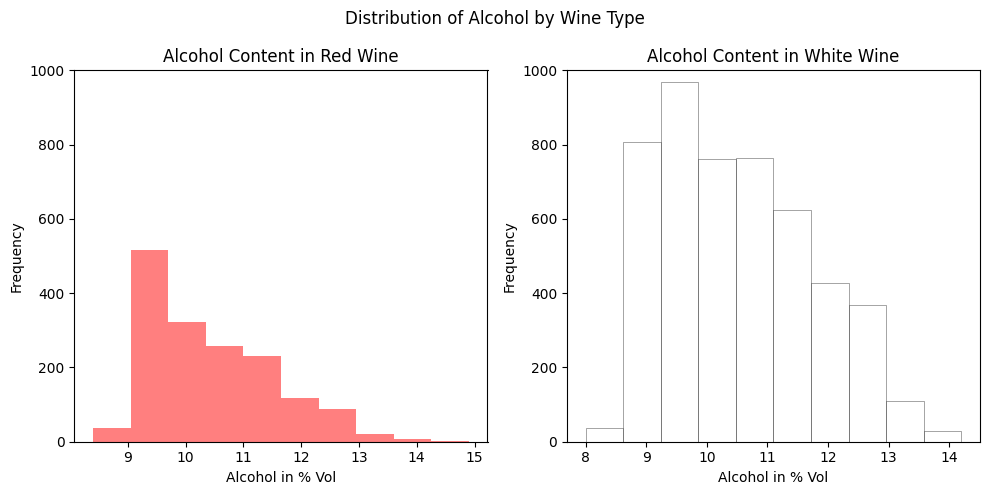

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(wines[wines['type'] == 1].alcohol, bins=10, facecolor='red', alpha=0.5, label='Red wine')
ax[1].hist(wines[wines['type'] == 0].alcohol, bins=10, facecolor='white', edgecolor='black', lw=0.5, alpha=0.5, label='White wine')

for a in ax:
    a.set_ylim([0, 1000])
    a.set_xlabel('Alcohol in % Vol')
    a.set_ylabel('Frequency')

ax[0].set_title('Alcohol Content in Red Wine')
ax[1].set_title('Alcohol Content in White Wine')

fig.suptitle('Distribution of Alcohol by Wine Type')
plt.tight_layout()
plt.show()

In [6]:
X = wines.iloc[:, :-1]
y = wines['type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.34, random_state=45)

In [7]:
model = Sequential()
model.add(Dense(12, activation='relu', input_dim=12))
model.add(Dense(9, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

c:\Users\onnok\NN-Project\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.fit(X_train, y_train, epochs=3, batch_size=1, verbose=1)

Epoch 1/3
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 3s 654us/step - accuracy: 0.9079 - loss: 0.2500
Epoch 2/3
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 3s 650us/step - accuracy: 0.9279 - loss: 0.2033
Epoch 3/3
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 3s 658us/step - accuracy: 0.9370 - loss: 0.1792


In [9]:
y_pred = model.predict(X_test)

y_pred_labels = (y_pred >= 0.5).astype(int)

for prediction in y_pred_labels[:12]:
    wine_type = "Red wine" if prediction == 1 else "White wine"
    print(f"Prediction: {wine_type}")

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step
Prediction: White wine
Prediction: White wine
Prediction: White wine
Prediction: White wine
Prediction: White wine
Prediction: Red wine
Prediction: Red wine
Prediction: White wine
Prediction: Red wine
Prediction: White wine
Prediction: White wine
Prediction: White wine


## prediction Fashion

In [10]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

In [11]:
print("My train data Shape:", train_data.shape)
print("My train labels :", train_labels.shape)
print("Maximum label : ", train_labels.max())

My train data Shape: (60000, 28, 28)
My train labels : (60000,)
Maximum label :  9


Text(0.5, 1.0, 'Bag')

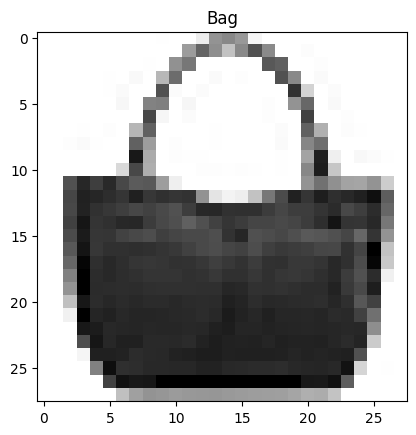

In [12]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
index_of_choice = 100
plt.imshow(train_data[index_of_choice],cmap=plt.cm.binary)
plt.title(class_names[train_labels[index_of_choice]])

In [13]:
train_data_norm = train_data / train_data.max()
test_data_norm = test_data / test_data.max()

In [14]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape= train_data[0].shape),
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(10, activation=tf.keras.activations.softmax)
])

model.compile(loss = tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer = tf.keras.optimizers.Adam(0.001),
                metrics = ["Accuracy"])
norm_history = model.fit(train_data_norm,train_labels,epochs=10,validation_data=(test_data_norm, test_labels))

Epoch 1/10


c:\Users\onnok\NN-Project\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 954us/step - Accuracy: 0.6258 - loss: 1.0208 - val_Accuracy: 0.7542 - val_loss: 0.7229
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 897us/step - Accuracy: 0.7706 - loss: 0.6581 - val_Accuracy: 0.7654 - val_loss: 0.6677
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 904us/step - Accuracy: 0.7871 - loss: 0.6135 - val_Accuracy: 0.7818 - val_loss: 0.6342
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 899us/step - Accuracy: 0.8002 - loss: 0.5820 - val_Accuracy: 0.7888 - val_loss: 0.6161
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 900us/step - Accuracy: 0.8062 - loss: 0.5634 - val_Accuracy: 0.7983 - val_loss: 0.5971
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 893us/step - Accuracy: 0.8107 - loss: 0.5507 - val_Accuracy: 0.8024 - val_loss: 0.5849
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 878us/step - Accuracy: 0.8129 - loss: 0.5406 - val_Accuracy: 0.8000 - val_loss: 0.5949
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 884us/step - Accuracy: 0.8156 - loss: 0.53

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 605us/step


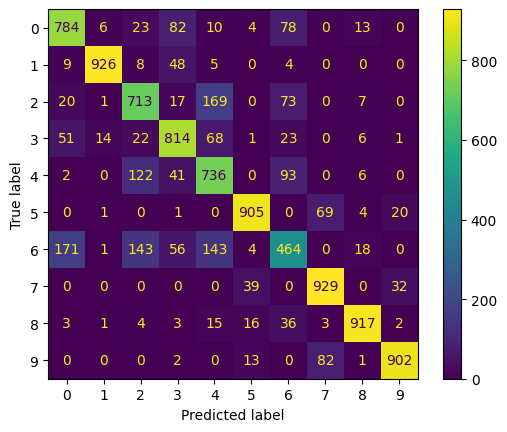

In [15]:
y_pred_probs = model.predict(test_data_norm)

# Hoogste kans kiezen
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion matrix maken
cm = confusion_matrix(test_labels, y_pred)

# Tonen
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

## Ameshousing

In [52]:
df = pd.read_excel("AmesHousing.xlsx")

In [53]:
 # Preprocessing
df["Garage"] = df["Garage"].map({"yes": 1, "no": 0})
df = pd.get_dummies(df, columns=["Neighborhood", "House Style"], drop_first=True)
 
X = df.drop(columns=["SalePrice", "ID"])
y = df["SalePrice"]
 
# Zet bool kolommen om naar int (get_dummies geeft bool terug)
X = X.astype({col: int for col in X.select_dtypes("bool").columns})
# Vul ontbrekende waarden op met de mediaan
X = X.fillna(X.median())

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)


scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()


In [55]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1)
])
 
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="mse",
    metrics=["mae"]
)
 
history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_data=(X_test_scaled, y_test_scaled),
    epochs=50,
    verbose=1
)


Epoch 1/50


c:\Users\onnok\NN-Project\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3782 - mae: 0.4027 - val_loss: 0.2206 - val_mae: 0.3036
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1712 - mae: 0.2720 - val_loss: 0.1557 - val_mae: 0.2617
Epoch 3/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1456 - mae: 0.2591 - val_loss: 0.1438 - val_mae: 0.2514
Epoch 4/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1299 - mae: 0.2394 - val_loss: 0.1500 - val_mae: 0.2517
Epoch 5/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1036 - mae: 0.2249 - val_loss: 0.1246 - val_mae: 0.2343
Epoch 6/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1048 - mae: 0.2245 - val_loss: 0.1296 - val_mae: 0.2405
Epoch 7/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0899 - mae: 0.2111 - val_loss: 0.1176 - val_mae: 0.2352
Epoch 8/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0993 - mae: 0.2166 - val_loss: 0.1511 - val_mae: 0.2612
Epoch 9/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0962 - mae: 0.2109 - va

In [56]:
from sklearn.metrics import mean_absolute_error

pred_train = scaler_y.inverse_transform(model.predict(X_train_scaled))
pred_test  = scaler_y.inverse_transform(model.predict(X_test_scaled))
 
mae_train = mean_absolute_error(y_train, pred_train)
mae_test  = mean_absolute_error(y_test,  pred_test)
print(f"MAE Train: €{mae_train:,.0f}")
print(f"MAE Test:  €{mae_test:,.0f}")



65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
MAE Train: €12,179
MAE Test:  €17,705


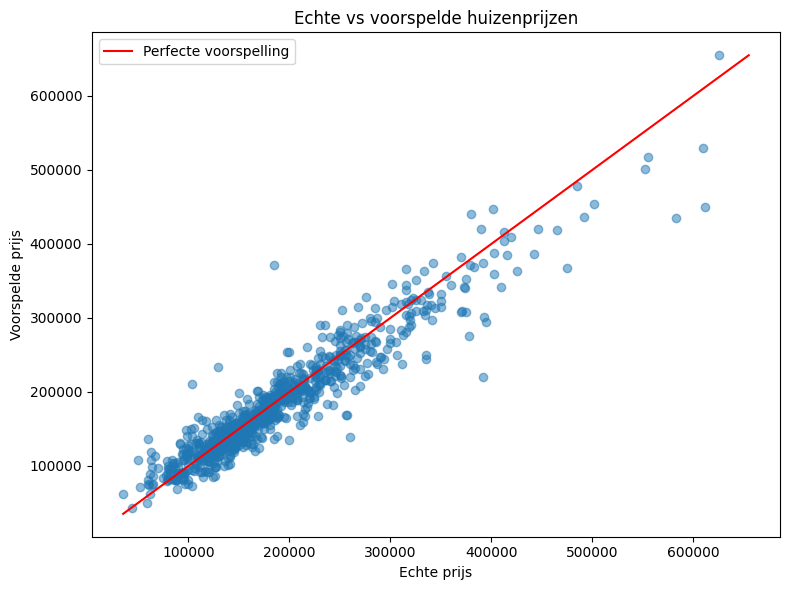

In [57]:

plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_test, alpha=0.5)
min_val = min(y_test.min(), pred_test.min())
max_val = max(y_test.max(), pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", label="Perfecte voorspelling")
plt.xlabel("Echte prijs")
plt.ylabel("Voorspelde prijs")
plt.title("Echte vs voorspelde huizenprijzen")
plt.legend()
plt.tight_layout()
plt.show()

## ames minder features

In [58]:
df = df.loc[:, ["SalePrice", "Overall Qual",
    "Gr Liv Area",
    "Total Bsmt SF",
    "Year Built"]]

df

,SalePrice,Overall Qual,Gr Liv Area,Total Bsmt SF,Year Built
0,215000,6,1656,1080.0,1960
1,105000,5,896,882.0,1961
2,172000,6,1329,1329.0,1958
3,244000,7,2110,2110.0,1968
4,189900,5,1629,928.0,1997
...,...,...,...,...,...
2925,142500,6,1003,1003.0,1984
2926,131000,5,902,864.0,1983
2927,132000,5,970,912.0,1992
2928,170000,5,1389,1389.0,1974


In [59]:
X = df.drop(["SalePrice"], axis=1)
y = df["SalePrice"]

# Zet bool kolommen om naar int (get_dummies geeft bool terug)
X = X.astype({col: int for col in X.select_dtypes("bool").columns})
# Vul ontbrekende waarden op met de mediaan
X = X.fillna(X.median())

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)


scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

In [61]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1)
])
 
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="mse",
    metrics=["mae"]
)
 
history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_data=(X_test_scaled, y_test_scaled),
    epochs=50,
    verbose=1
)


Epoch 1/50


c:\Users\onnok\NN-Project\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2841 - mae: 0.3338 - val_loss: 0.1814 - val_mae: 0.2691
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1850 - mae: 0.2693 - val_loss: 0.1667 - val_mae: 0.2633
Epoch 3/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1716 - mae: 0.2625 - val_loss: 0.1585 - val_mae: 0.2544
Epoch 4/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1579 - mae: 0.2602 - val_loss: 0.1627 - val_mae: 0.2564
Epoch 5/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1505 - mae: 0.2549 - val_loss: 0.1557 - val_mae: 0.2539
Epoch 6/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1457 - mae: 0.2520 - val_loss: 0.1642 - val_mae: 0.2558
Epoch 7/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1464 - mae: 0.2552 - val_loss: 0.1516 - val_mae: 0.2486
Epoch 8/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1370 - mae: 0.2516 - val_loss: 0.1500 - val_mae: 0.2463
Epoch 9/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1407 - mae: 0.2580 - va

In [62]:
from sklearn.metrics import mean_absolute_error

pred_train = scaler_y.inverse_transform(model.predict(X_train_scaled))
pred_test  = scaler_y.inverse_transform(model.predict(X_test_scaled))
 
mae_train = mean_absolute_error(y_train, pred_train)
mae_test  = mean_absolute_error(y_test,  pred_test)
print(f"MAE Train: €{mae_train:,.0f}")
print(f"MAE Test:  €{mae_test:,.0f}")



65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
MAE Train: €17,841
MAE Test:  €18,693


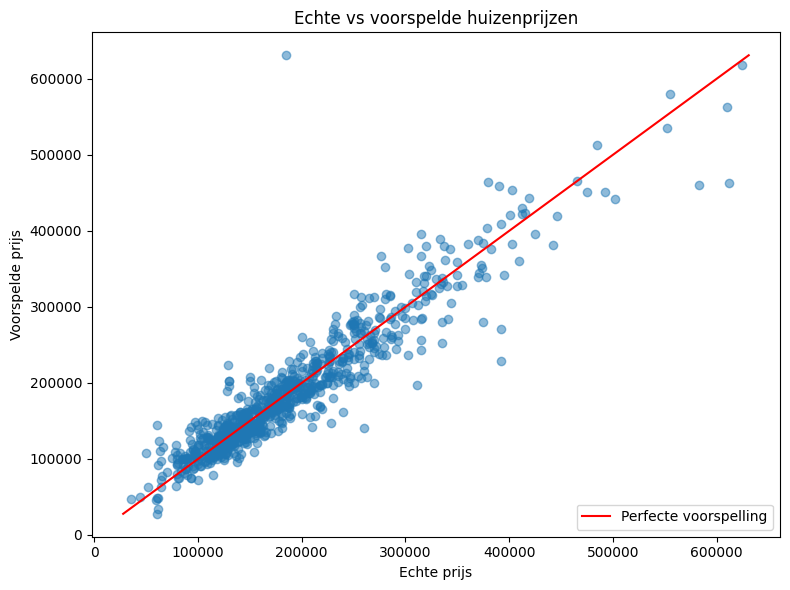

In [63]:

plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_test, alpha=0.5)
min_val = min(y_test.min(), pred_test.min())
max_val = max(y_test.max(), pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", label="Perfecte voorspelling")
plt.xlabel("Echte prijs")
plt.ylabel("Voorspelde prijs")
plt.title("Echte vs voorspelde huizenprijzen")
plt.legend()
plt.tight_layout()
plt.show()